In [ ]:
#농어의 길이와 무게 데이터 입력
import numpy as np

perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

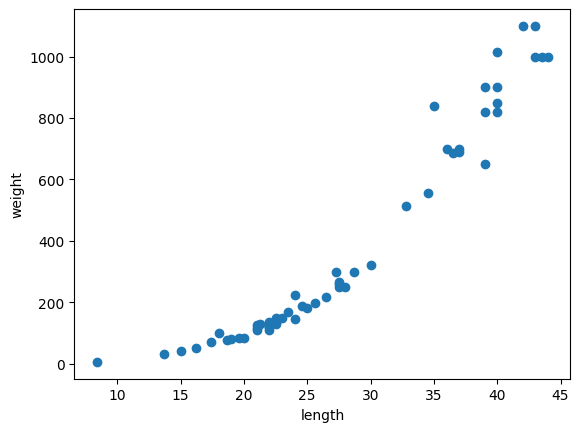

In [ ]:
#길이를 x축, 무게를 y축으로 하여 농어의 데이터 시각화

import matplotlib.pyplot as plt
plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
#train set과 test set의 분할

from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state = 42)

In [ ]:
#데이터가 42개인 한 줄짜리 배열, 데이터가 14개인 한 줄짜리 배열. 데이터들의 shape 확인
print(train_input.shape, test_input.shape)

(42,) (14,)


In [ ]:
#reshape 함수 연습, 1차원 배열을 2차원 배열로 바꿔줌. (ex. [1,2,3,4] -> [[1,2],[3,4]])
test_array = np.array([1,2,3,4])
print(test_array.shape)

test_array = test_array.reshape(2, 2)
print(test_array.shape)

(4,)
(2, 2)


In [ ]:
#reshape()메서드 : (샘플, 특성), -1이면 알아서 계산
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)
print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


In [ ]:
#k-최근접 이웃 회귀 알고리즘
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor()
knr.fit(train_input, train_target)

#score() >> test set의 점수, 0.99... 모델이 설명을 잘한다.
knr.score(test_input, test_target)


0.992809406101064

In [ ]:
#평균 절댓값 오차(MAE)를 구함, 평균적으로 실제 무게보다 19g정도 차이 남,
from sklearn.metrics import mean_absolute_error

test_prediction = knr.predict(test_input)
mae = mean_absolute_error(test_target, test_prediction)
print(mae)

19.157142857142862


In [ ]:
#test 점수가 더 높다, 시험을 더 잘 본 것. 과소적합 발생.
print(knr.score(train_input, train_target))
knr.score(test_input, test_target)

0.9698823289099254


0.992809406101064

In [ ]:
#k=5로 설정되어 있어서 전체적 패턴만 반영, 특정한 성질을 나타내지 못함. k를 작게 설정, 과소적합 문제 해결
knr.n_neighbors = 3

knr.fit(train_input, train_target)
print(knr.score(train_input, train_target))
print(knr.score(test_input, test_target))

0.9804899950518966
0.9746459963987609


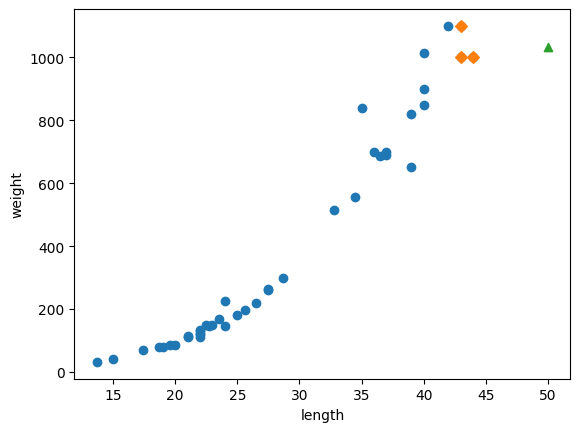

In [ ]:
# 50cm 농어의 이웃 구하기
import matplotlib.pyplot as plt

distances, indexes = knr.kneighbors([[50]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')
plt.scatter(50, 1033, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
print(np.mean(train_target[indexes]))
print(knr.predict([[100]]))

1033.3333333333333
[1033.33333333]


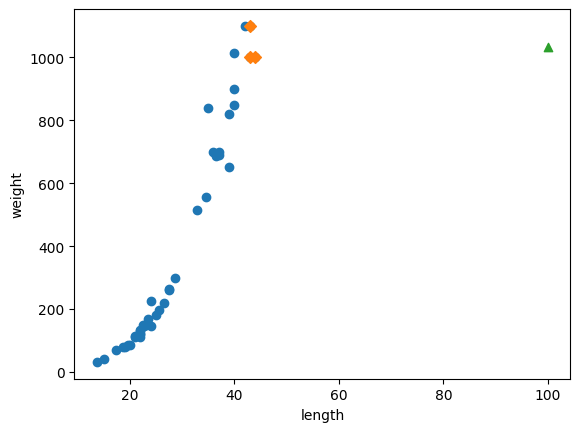

In [ ]:
# 100cm 농어의 이웃 구하기, 100cm든 50cm든 이웃이 같고 결과적으로 이웃 사이의 평균으로만 값이 한정됨.
distances, indexes = knr.kneighbors([[100]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')
plt.scatter(100, 1033, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
#sol:선형 회귀(다른 알고리즘)을 써보자. 직선(y=ax+b)을 학습하는 알고리즘.
#x,y는 우리가 아는 값으로 입력하는 것.
#a,b는 우리가 모르는 값으로 모델이 학습하면서 조절하는 것.

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_input, train_target)

#knn보다 나은 결과값
print(lr.predict([[50]]))
print(lr.coef_, lr.intercept_)

#과적합 발생 안함.
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

[1241.83860323]
[39.01714496] -709.0186449535477
0.939846333997604
0.8247503123313558


In [ ]:
#선형 회귀는 그래프 왼쪽 아래같은 데이터들을 설명하지 못함
#sol : 다항회귀 이용, 곡선으로 데이터를 파악하는 회귀
#이차방정식의 형태, x²에 해당하는 데이터값 생성

train_poly = np.column_stack((train_input ** 2, train_input))
test_poly = np.column_stack((test_input ** 2, test_input))

#특성이 x와 x², 2개가 됨
print(train_poly.shape, test_poly.shape)

(42, 2) (14, 2)


In [ ]:
lr = LinearRegression()
lr.fit(train_poly, train_target)

#아까보다 무게가 더 많이 나간다.
print(lr.predict([[50**2, 50]]))
print(lr.coef_, lr.intercept_)

[1573.98423528]
[  1.01433211 -21.55792498] 116.0502107827827


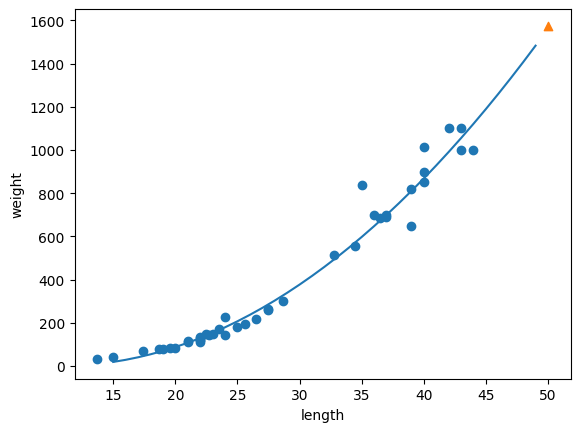

In [ ]:
point = np.arange(15, 50)
plt.scatter(train_input, train_target)
plt.plot(point, 1.01*point**2 - 21.6*point + 116.05)
plt.scatter([50], [1574], marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
#여전히 test값이 더 높은 과소적합.
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9706807451768623
0.9775935108325122


In [ ]:
#한가지 특성만으로 농어의 무게를 판단하기엔 한계가 있다 -> 다중회귀
#다중회귀 : 여러 개의 특성을 사용한 선형회귀
#특성이 많아지니 엑셀 파일을 읽어오자.

import pandas as pd

df = pd.read_csv('https://bit.ly/perch_csv_data')
perch_full = df.to_numpy()
print(perch_full)

[[ 8.4   2.11  1.41]
 [13.7   3.53  2.  ]
 [15.    3.82  2.43]
 [16.2   4.59  2.63]
 [17.4   4.59  2.94]
 [18.    5.22  3.32]
 [18.7   5.2   3.12]
 [19.    5.64  3.05]
 [19.6   5.14  3.04]
 [20.    5.08  2.77]
 [21.    5.69  3.56]
 [21.    5.92  3.31]
 [21.    5.69  3.67]
 [21.3   6.38  3.53]
 [22.    6.11  3.41]
 [22.    5.64  3.52]
 [22.    6.11  3.52]
 [22.    5.88  3.52]
 [22.    5.52  4.  ]
 [22.5   5.86  3.62]
 [22.5   6.79  3.62]
 [22.7   5.95  3.63]
 [23.    5.22  3.63]
 [23.5   6.28  3.72]
 [24.    7.29  3.72]
 [24.    6.38  3.82]
 [24.6   6.73  4.17]
 [25.    6.44  3.68]
 [25.6   6.56  4.24]
 [26.5   7.17  4.14]
 [27.3   8.32  5.14]
 [27.5   7.17  4.34]
 [27.5   7.05  4.34]
 [27.5   7.28  4.57]
 [28.    7.82  4.2 ]
 [28.7   7.59  4.64]
 [30.    7.62  4.77]
 [32.8  10.03  6.02]
 [34.5  10.26  6.39]
 [35.   11.49  7.8 ]
 [36.5  10.88  6.86]
 [36.   10.61  6.74]
 [37.   10.84  6.26]
 [37.   10.57  6.37]
 [39.   11.14  7.49]
 [39.   11.14  6.  ]
 [39.   12.43  7.35]
 [40.   11.93

In [ ]:
import numpy as np

perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

In [ ]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(perch_full, perch_weight, random_state=42)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures()
poly.fit([[2, 3]])
print(poly.transform([[2, 3]]))

#특성공학 적용
poly = PolynomialFeatures(include_bias=False)
poly.fit([[2, 3]])
print(poly.transform([[2, 3]]))

[[1. 2. 3. 4. 6. 9.]]
[[2. 3. 4. 6. 9.]]


In [ ]:
poly = PolynomialFeatures(include_bias=False)

poly.fit(train_input)
train_poly = poly.transform(train_input)

#변환 후 shape
print(train_poly.shape)

(42, 9)


In [ ]:
poly.get_feature_names_out()
test_poly = poly.transform(test_input)

In [ ]:
#다중 회귀 모델 훈련, 다중회귀 = 선형회귀
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9903183436982125
0.9714559911594111


In [ ]:
#degree = 5로 변경, 총 특성수는 1차+2차+...+5차 = 55개
poly = PolynomialFeatures(degree=5, include_bias=False)

poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

In [ ]:
print(train_poly.shape)

(42, 55)


In [ ]:
#심한 과대적합 발생

lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))


0.9999999999996433
-144.40579436844948


In [ ]:
#스케일링. StandardScaler 클래스를 사용하여 trian_scaled, test_scaled로 변환
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_poly)

train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

In [ ]:
#규제 중 릿지, 모든 계수를 작게 유지하려고 함.
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9896101671037343
0.9790693977615387


In [ ]:
#규제 중 라쏘, 특정 계수를 0으로 만듦.
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))


0.989789897208096
0.9800593698421883


In [ ]:
# degree=15로 설정하여, 다중 회귀 모델을 학습해주세요.
# 이후, train/test score을 출력하여 과적합 여부를 확인해주세요.

poly = PolynomialFeatures(degree=15, include_bias=False)

poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

In [ ]:
#과대적합 발생

lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))


0.9998902131353397
-7673.092912495012


In [ ]:
# StandardScaler로 데이터를 스케일링한 후 Ridge 또는 Lasso 규제를 적용해주세요.
# 이후, 규제 후의 train/test score을 출력하여 과적합이 완화되었는지 확인해주세요.

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_poly)

train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9945264104805062
0.9982885148309885


In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

0.9918278026575231
0.9923585380814085


In [ ]:
#미묘하게 시험 점수가 더 높다. 과적합이 전보다는 완화됐지만....뭔가 찜찜.